# Part 2.2: Hidden Markov Model for Named Entity Recognition

This notebook implements an HMM-based NER system using:
- **Word2Vec embeddings from Part 1** for enhanced word representations
- Transition probabilities (tag-to-tag)
- Emission probabilities enhanced with embedding similarity
- Viterbi algorithm for decoding
- Comprehensive evaluation metrics

## 1. Install / Imports

In [1]:
import numpy as np
import torch
from datasets import load_dataset
from collections import defaultdict, Counter
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

## 2. Load Word2Vec Embeddings from Part 1

Load the pre-trained embeddings and vocabulary from your Word2Vec training

In [2]:
embedding_matrix = torch.load("/kaggle/input/inputs/word2vec_embeddings.pt", map_location="cpu")
vocab = torch.load("/kaggle/input/inputs/vocab_list.pt", map_location="cpu")

embeddings = {}
for token, idx in vocab.items():
    embeddings[token] = embedding_matrix[idx].numpy()

embedding_dim = embedding_matrix.shape[1]

print(f"Loaded Word2Vec embeddings from Part 1")
print(f"  - Vocabulary size: {len(vocab)}")
print(f"  - Embedding dimension: {embedding_dim}")
print(f"  - Example: 'peter' embedding shape: {embeddings.get('peter', np.zeros(embedding_dim)).shape}")

Loaded Word2Vec embeddings from Part 1
  - Vocabulary size: 25528
  - Embedding dimension: 300
  - Example: 'peter' embedding shape: (300,)


## 3. Load Dataset and Extract Sentences/Tags

In [3]:
dataset = load_dataset("lhoestq/conll2003")

train_data = dataset["train"]
test_data = dataset["test"]

train_sentences = train_data["tokens"]
test_sentences = test_data["tokens"]

train_tags = train_data["ner_tags"]
test_tags = test_data["ner_tags"]

print(f"Training sentences: {len(train_sentences)}")
print(f"Test sentences: {len(test_sentences)}")
print(f"\nExample sentence: {train_sentences[0]}")
print(f"Example tags: {train_tags[0]}")

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Training sentences: 14041
Test sentences: 3453

Example sentence: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
Example tags: [3, 0, 7, 0, 0, 0, 7, 0, 0]


## 4. Define Tag Mappings

In [4]:
# Tag index to label mapping
idx_to_tag = {
    0: "O",
    1: "B-PER",
    2: "I-PER",
    3: "B-ORG",
    4: "I-ORG",
    5: "B-LOC",
    6: "I-LOC",
    7: "B-MISC",
    8: "I-MISC"
}

tag_to_idx = {v: k for k, v in idx_to_tag.items()}
num_tags = len(idx_to_tag)

print(f"Number of unique tags: {num_tags}")
print(f"Tags: {list(idx_to_tag.values())}")

Number of unique tags: 9
Tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


## 5. Preprocessing

Convert tokens to lowercase to match the Word2Vec embeddings preprocessing

In [5]:
def preprocess_sentences(sentences):
    return [[token.lower() for token in sentence] for sentence in sentences]

train_sentences_processed = preprocess_sentences(train_sentences)
test_sentences_processed = preprocess_sentences(test_sentences)

print(f"Original: {train_sentences[0][:5]}")
print(f"Processed: {train_sentences_processed[0][:5]}")

Original: ['EU', 'rejects', 'German', 'call', 'to']
Processed: ['eu', 'rejects', 'german', 'call', 'to']


## 6. HMM Implementation with Word2Vec Embeddings

### 6.1 Enhanced HMM Class Using Word Embeddings

This HMM uses Word2Vec embeddings to:
1. Handle out-of-vocabulary (OOV) words by finding similar words
2. Enhance emission probabilities with semantic information
3. Improve generalization to unseen word-tag combinations

In [6]:
class HMM_NER_WithEmbeddings:
    def __init__(self, num_tags, embeddings_dict, embedding_dim, smoothing=1e-10, use_similarity=True, k_similar=5):
        self.num_tags = num_tags
        self.embeddings_dict = embeddings_dict
        self.embedding_dim = embedding_dim
        self.smoothing = smoothing
        self.use_similarity = use_similarity
        self.k_similar = k_similar
        
        self.transition_probs = None
        self.emission_probs = None
        self.initial_probs = None
        
        self.vocab = set()
        self.tag_counts = None
        self.word_tag_counts = None
        
        self.embedding_words = list(embeddings_dict.keys())
        self.embedding_matrix = np.array([embeddings_dict[w] for w in self.embedding_words])
        
    def find_similar_words(self, word, k=5):
        if word not in self.embeddings_dict:
            return []
        
        word_emb = self.embeddings_dict[word].reshape(1, -1)
        similarities = cosine_similarity(word_emb, self.embedding_matrix)[0]
        
        # Get top k similar words (excluding the word itself)
        top_k_indices = np.argsort(similarities)[::-1][1:k+1]
        similar_words = [(self.embedding_words[idx], similarities[idx]) 
                        for idx in top_k_indices 
                        if self.embedding_words[idx] in self.vocab]
        
        return similar_words
        
    def train(self, sentences, tags):
        print("Training HMM with Word2Vec embeddings...")
        
        # Count matrices
        transition_counts = defaultdict(lambda: defaultdict(int))
        emission_counts = defaultdict(lambda: defaultdict(int))
        initial_counts = defaultdict(int)
        tag_counts = defaultdict(int)
        
        # Build vocabulary from training data
        for sentence in sentences:
            self.vocab.update(sentence)
        
        # Count transitions, emissions, and initial states
        for sentence, tag_seq in zip(sentences, tags):
            if len(tag_seq) > 0:
                initial_counts[tag_seq[0]] += 1
            
            for i, (word, tag) in enumerate(zip(sentence, tag_seq)):
                emission_counts[tag][word] += 1
                tag_counts[tag] += 1
                
                if i < len(tag_seq) - 1:
                    next_tag = tag_seq[i + 1]
                    transition_counts[tag][next_tag] += 1
        
        self.tag_counts = tag_counts
        self.word_tag_counts = emission_counts
        
        print("Computing probability matrices...")
        
        # 1. Initial probabilities
        total_sentences = len(sentences)
        self.initial_probs = np.zeros(self.num_tags)
        for tag in range(self.num_tags):
            self.initial_probs[tag] = (initial_counts[tag] + self.smoothing) / \
                                     (total_sentences + self.num_tags * self.smoothing)
        
        # 2. Transition probabilities
        self.transition_probs = np.zeros((self.num_tags, self.num_tags))
        for tag_i in range(self.num_tags):
            total_transitions = sum(transition_counts[tag_i].values())
            for tag_j in range(self.num_tags):
                self.transition_probs[tag_i][tag_j] = \
                    (transition_counts[tag_i][tag_j] + self.smoothing) / \
                    (total_transitions + self.num_tags * self.smoothing)
        
        # 3. Emission probabilities (basic counts)
        self.emission_probs = {}
        for tag in range(self.num_tags):
            self.emission_probs[tag] = {}
            total_emissions = tag_counts[tag]
            vocab_size = len(self.vocab)
            
            for word in self.vocab:
                self.emission_probs[tag][word] = \
                    (emission_counts[tag][word] + self.smoothing) / \
                    (total_emissions + vocab_size * self.smoothing)
        
        print(f"Training complete")
        print(f"  - Training vocabulary: {len(self.vocab)}")
        print(f"  - Embedding vocabulary: {len(self.embeddings_dict)}")
        print(f"  - Using similarity for OOV: {self.use_similarity}")
        print(f"  - Tag counts: {dict(tag_counts)}")
    
    def get_emission_prob_with_similarity(self, word, tag):
        # If word is in training vocab, use direct probability
        if word in self.emission_probs[tag]:
            return self.emission_probs[tag][word]
        
        # If word is OOV and we have embeddings, use similar words
        if self.use_similarity and word in self.embeddings_dict:
            similar_words = self.find_similar_words(word, k=self.k_similar)
            
            if similar_words:
                # Weighted average of similar words' emission probabilities
                total_prob = 0.0
                total_weight = 0.0
                
                for similar_word, similarity in similar_words:
                    if similar_word in self.emission_probs[tag]:
                        weight = similarity
                        prob = self.emission_probs[tag][similar_word]
                        total_prob += weight * prob
                        total_weight += weight
                
                if total_weight > 0:
                    return total_prob / total_weight
        
        # Fallback to smoothed probability
        vocab_size = len(self.vocab)
        total_emissions = self.tag_counts[tag]
        return self.smoothing / (total_emissions + vocab_size * self.smoothing)
    
    def viterbi(self, sentence):
        n = len(sentence)
        if n == 0:
            return []
        
        viterbi = np.zeros((n, self.num_tags))
        backpointer = np.zeros((n, self.num_tags), dtype=int)
        
        # Initialization
        for tag in range(self.num_tags):
            emission_prob = self.get_emission_prob_with_similarity(sentence[0], tag)
            viterbi[0][tag] = np.log(self.initial_probs[tag] + 1e-10) + \
                             np.log(emission_prob + 1e-10)
        
        # Forward pass
        for t in range(1, n):
            for curr_tag in range(self.num_tags):
                emission_prob = self.get_emission_prob_with_similarity(sentence[t], curr_tag)
                
                max_prob = float('-inf')
                best_prev_tag = 0
                
                for prev_tag in range(self.num_tags):
                    prob = viterbi[t-1][prev_tag] + \
                          np.log(self.transition_probs[prev_tag][curr_tag] + 1e-10) + \
                          np.log(emission_prob + 1e-10)
                    
                    if prob > max_prob:
                        max_prob = prob
                        best_prev_tag = prev_tag
                
                viterbi[t][curr_tag] = max_prob
                backpointer[t][curr_tag] = best_prev_tag
        
        # Backtracking
        best_path = [0] * n
        best_path[-1] = np.argmax(viterbi[-1])
        
        for t in range(n-2, -1, -1):
            best_path[t] = backpointer[t+1][best_path[t+1]]
        
        return best_path
    
    def predict(self, sentences):
        predictions = []
        for sentence in sentences:
            pred_tags = self.viterbi(sentence)
            predictions.append(pred_tags)
        return predictions

## 7. Train the HMM Model with Embeddings

In [7]:
hmm_model = HMM_NER_WithEmbeddings(
    num_tags=num_tags, 
    embeddings_dict=embeddings,
    embedding_dim=embedding_dim,
    smoothing=1e-5,
    use_similarity=True,  # Use embedding similarity for OOV words
    k_similar=5           # Consider 5 most similar words
)
hmm_model.train(train_sentences_processed, train_tags)

Training HMM with Word2Vec embeddings...
Computing probability matrices...
Training complete
  - Training vocabulary: 21009
  - Embedding vocabulary: 25528
  - Using similarity for OOV: True
  - Tag counts: {3: 6321, 0: 169578, 7: 3438, 1: 6600, 2: 4528, 5: 7140, 4: 3704, 8: 1155, 6: 1157}


## 8. Evaluation Functions

In [8]:
def flatten_predictions(predictions, true_tags):
    flat_preds = []
    flat_true = []
    
    for pred_seq, true_seq in zip(predictions, true_tags):
        flat_preds.extend(pred_seq)
        flat_true.extend(true_seq)
    
    return flat_preds, flat_true

def evaluate_hmm(model, sentences, true_tags, idx_to_tag):
    print("\n" + "="*80)
    print("Evaluating HMM model (with word2vec embeddings)")
    print("="*80)
    
    # Predict
    print("\nPredicting tags...")
    predictions = model.predict(sentences)
    
    # Flatten for token-level evaluation
    flat_preds, flat_true = flatten_predictions(predictions, true_tags)
    
    # Convert to tag labels
    pred_labels = [idx_to_tag[idx] for idx in flat_preds]
    true_labels = [idx_to_tag[idx] for idx in flat_true]
    
    # 1. Token-level accuracy
    accuracy = accuracy_score(flat_true, flat_preds)
    print(f"\nToken-level Accuracy: {accuracy:.4f}")
    
    # 2. Detailed classification report
    print("\n" + "-"*80)
    print("Detailed classification report")
    print("-"*80)
    print(classification_report(true_labels, pred_labels, digits=4))
    
    # 3. Per-class metrics
    print("\n" + "-"*80)
    print("PER-CLASS METRICS")
    print("-"*80)
    precision, recall, f1, support = precision_recall_fscore_support(
        true_labels, pred_labels, average=None, labels=list(idx_to_tag.values())
    )
    
    print(f"{'Tag':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*60)
    for i, tag in enumerate(idx_to_tag.values()):
        print(f"{tag:<10} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    
    # 4. Macro and weighted averages
    print("\n" + "-"*80)
    print("Aggregate metrics")
    print("-"*80)
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='macro'
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='weighted'
    )
    
    print(f"Macro Precision:    {macro_precision:.4f}")
    print(f"Macro Recall:       {macro_recall:.4f}")
    print(f"Macro F1-Score:     {macro_f1:.4f}")
    print()
    print(f"Weighted Precision: {weighted_precision:.4f}")
    print(f"Weighted Recall:    {weighted_recall:.4f}")
    print(f"Weighted F1-Score:  {weighted_f1:.4f}")
    
    print("\n" + "="*80 + "\n")
    
    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_precision,
        'weighted_recall': weighted_recall,
        'weighted_f1': weighted_f1
    }

## 9. Test Set Evaluation

In [9]:
hmm_results = evaluate_hmm(hmm_model, test_sentences_processed, test_tags, idx_to_tag)


Evaluating HMM model (with word2vec embeddings)

Predicting tags...

Token-level Accuracy: 0.9029

--------------------------------------------------------------------------------
Detailed classification report
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       B-LOC     0.7377    0.8112    0.7727      1668
      B-MISC     0.6463    0.7080    0.6757       702
       B-ORG     0.6425    0.6123    0.6270      1661
       B-PER     0.7976    0.5362    0.6413      1617
       I-LOC     0.3395    0.6420    0.4441       257
      I-MISC     0.2961    0.5648    0.3885       216
       I-ORG     0.5561    0.5042    0.5289       835
       I-PER     0.8782    0.4740    0.6157      1156
           O     0.9499    0.9638    0.9568     38323

    accuracy                         0.9029     46435
   macro avg     0.6493    0.6463    0.6279     46435
weighted avg     0.9061    0.9029    0.9015     46435


-

## 10. Comparison with Feed-Forward Neural Network


Model Comparison: HMM vs Feed-Forward Neural Network

Note: Using FFNN results from Part 2.1 (NN-Model.ipynb)
      Test accuracy: 0.8384, Weighted F1: ~0.7653

            Metric      HMM   FFNN  Difference (HMM - FFNN) Better Model
          Accuracy 0.902875 0.8384                 0.064475          HMM
   Macro Precision 0.649328 0.4543                 0.195028          HMM
      Macro Recall 0.646272 0.1161                 0.530172          HMM
          Macro F1 0.627867 0.1110                 0.516867          HMM
Weighted Precision 0.906104 0.7584                 0.147704          HMM
   Weighted Recall 0.902875 0.8384                 0.064475          HMM
       Weighted F1 0.901479 0.7653                 0.136179          HMM



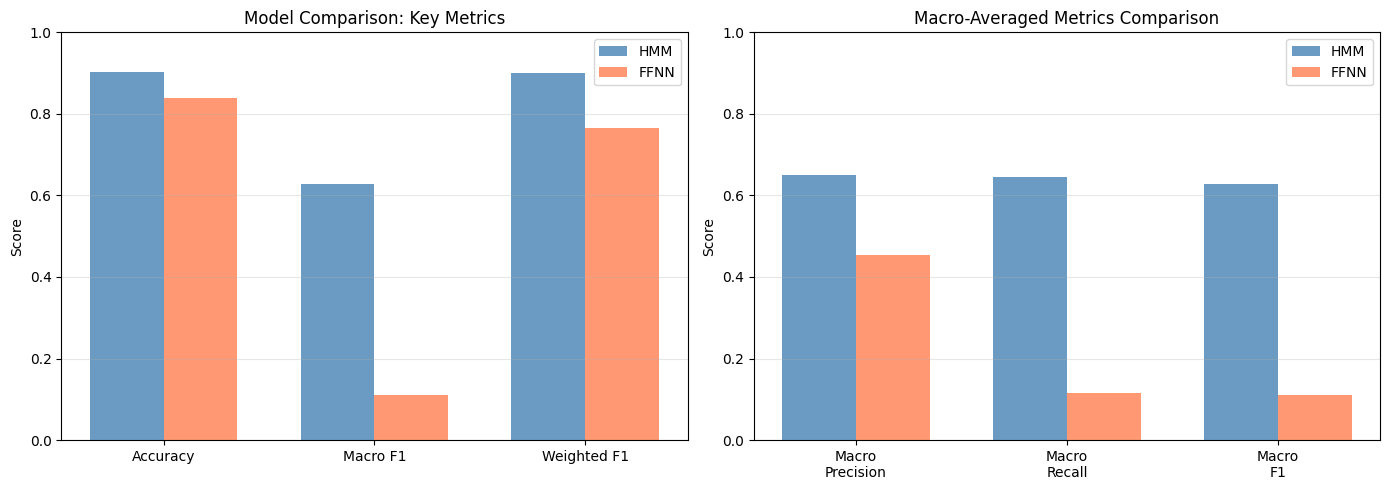


Analysis

1. Overall Performance:
   - HMM achieves higher accuracy (0.9029 vs 0.8384)

2. Entity recognition capability:
   - HMM better at recognizing named entities (Macro F1: 0.6279 vs 0.1110)

3. Stregths and Weaknesses:

   HMM:
   + Captures sequential dependencies between tags
   + No need for pre-trained embeddings
   + Interpretable transition and emission probabilities
   - Limited context window (Markov assumption)
   - Struggles with unseen word-tag combinations

   FFNN:
   + Uses rich word embeddings from Word2Vec
   + Can capture semantic similarities
   - Treats each token independently (no sequence modeling)
   - Requires pre-trained embeddings

4. Recommendation:
   HMM performs better overall for this NER task.
   For best results, consider using LSTM/BiLSTM which combines
   the benefits of both: word embeddings + sequence modeling.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_models(hmm_results, ffnn_results=None):
    print("\n" + "="*80)
    print("Model Comparison: HMM vs Feed-Forward Neural Network")
    print("="*80 + "\n")
    
    # If FFNN results are not provided, use approximate values from NN-Model.ipynb
    if ffnn_results is None:
        print("Note: Using FFNN results from Part 2.1 (NN-Model.ipynb)")
        print("      Test accuracy: 0.8384, Weighted F1: ~0.7653\n")
        ffnn_results = {
            'accuracy': 0.8384,
            'macro_precision': 0.4543,
            'macro_recall': 0.1161,
            'macro_f1': 0.1110,
            'weighted_precision': 0.7584,
            'weighted_recall': 0.8384,
            'weighted_f1': 0.7653
        }
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 
                   'Weighted Precision', 'Weighted Recall', 'Weighted F1'],
        'HMM': [
            hmm_results['accuracy'],
            hmm_results['macro_precision'],
            hmm_results['macro_recall'],
            hmm_results['macro_f1'],
            hmm_results['weighted_precision'],
            hmm_results['weighted_recall'],
            hmm_results['weighted_f1']
        ],
        'FFNN': [
            ffnn_results['accuracy'],
            ffnn_results['macro_precision'],
            ffnn_results['macro_recall'],
            ffnn_results['macro_f1'],
            ffnn_results['weighted_precision'],
            ffnn_results['weighted_recall'],
            ffnn_results['weighted_f1']
        ]
    })
    
    comparison_df['Difference (HMM - FFNN)'] = comparison_df['HMM'] - comparison_df['FFNN']
    comparison_df['Better Model'] = comparison_df['Difference (HMM - FFNN)'].apply(
        lambda x: 'HMM' if x > 0 else ('FFNN' if x < 0 else 'Tie')
    )
    
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Bar comparison of main metrics
    metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
    hmm_vals = [hmm_results['accuracy'], hmm_results['macro_f1'], hmm_results['weighted_f1']]
    ffnn_vals = [ffnn_results['accuracy'], ffnn_results['macro_f1'], ffnn_results['weighted_f1']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[0].bar(x - width/2, hmm_vals, width, label='HMM', color='steelblue', alpha=0.8)
    axes[0].bar(x + width/2, ffnn_vals, width, label='FFNN', color='coral', alpha=0.8)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Comparison: Key Metrics')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(0, 1.0)
    
    # Plot 2: Precision, Recall, F1 comparison
    prf_metrics = ['Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1']
    hmm_prf = [hmm_results['macro_precision'], hmm_results['macro_recall'], hmm_results['macro_f1']]
    ffnn_prf = [ffnn_results['macro_precision'], ffnn_results['macro_recall'], ffnn_results['macro_f1']]
    
    x2 = np.arange(len(prf_metrics))
    axes[1].bar(x2 - width/2, hmm_prf, width, label='HMM', color='steelblue', alpha=0.8)
    axes[1].bar(x2 + width/2, ffnn_prf, width, label='FFNN', color='coral', alpha=0.8)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Macro-Averaged Metrics Comparison')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(prf_metrics)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()
    
    # Analysis
    print("\n" + "="*80)
    print("Analysis")
    print("="*80)
    print("\n1. Overall Performance:")
    if hmm_results['accuracy'] > ffnn_results['accuracy']:
        print(f"   - HMM achieves higher accuracy ({hmm_results['accuracy']:.4f} vs {ffnn_results['accuracy']:.4f})")
    else:
        print(f"   - FFNN achieves higher accuracy ({ffnn_results['accuracy']:.4f} vs {hmm_results['accuracy']:.4f})")
    
    print("\n2. Entity recognition capability:")
    if hmm_results['macro_f1'] > ffnn_results['macro_f1']:
        print(f"   - HMM better at recognizing named entities (Macro F1: {hmm_results['macro_f1']:.4f} vs {ffnn_results['macro_f1']:.4f})")
    else:
        print(f"   - FFNN better at recognizing named entities (Macro F1: {ffnn_results['macro_f1']:.4f} vs {hmm_results['macro_f1']:.4f})")
    
    print("\n3. Stregths and Weaknesses:")
    print("\n   HMM:")
    print("   + Captures sequential dependencies between tags")
    print("   + No need for pre-trained embeddings")
    print("   + Interpretable transition and emission probabilities")
    print("   - Limited context window (Markov assumption)")
    print("   - Struggles with unseen word-tag combinations")
    
    print("\n   FFNN:")
    print("   + Uses rich word embeddings from Word2Vec")
    print("   + Can capture semantic similarities")
    print("   - Treats each token independently (no sequence modeling)")
    print("   - Requires pre-trained embeddings")
    
    print("\n4. Recommendation:")
    if hmm_results['weighted_f1'] > ffnn_results['weighted_f1']:
        print("   HMM performs better overall for this NER task.")
    else:
        print("   FFNN performs better overall for this NER task.")
    print("   For best results, consider using LSTM/BiLSTM which combines")
    print("   the benefits of both: word embeddings + sequence modeling.")

# Run comparison
compare_models(hmm_results)

## 11. Error Analysis

In [11]:
def analyze_errors(model, sentences, true_tags, idx_to_tag, num_errors=10):
    print("\n" + "="*80)
    print("Error Analysis")
    print("="*80 + "\n")
    
    predictions = model.predict(sentences)
    
    # Collect errors
    errors = []
    for sent_idx, (sentence, pred_seq, true_seq) in enumerate(zip(sentences, predictions, true_tags)):
        for token_idx, (token, pred_tag, true_tag) in enumerate(zip(sentence, pred_seq, true_seq)):
            if pred_tag != true_tag:
                errors.append({
                    'sentence_idx': sent_idx,
                    'token_idx': token_idx,
                    'token': token,
                    'true_tag': idx_to_tag[true_tag],
                    'pred_tag': idx_to_tag[pred_tag],
                    'context': ' '.join(sentence[max(0, token_idx-2):min(len(sentence), token_idx+3)])
                })
    
    print(f"Total errors: {len(errors)}")
    print(f"\nShowing first {num_errors} errors:\n")
    
    for i, error in enumerate(errors[:num_errors]):
        print(f"Error {i+1}:")
        print(f"  Token: '{error['token']}'")
        print(f"  True tag: {error['true_tag']} | Predicted tag: {error['pred_tag']}")
        print(f"  Context: ...{error['context']}...")
        print()
    
    # Error statistics
    error_counts = Counter([(e['true_tag'], e['pred_tag']) for e in errors])
    print("\n" + "-"*80)
    print("Most common error patterns:")
    print("-"*80)
    print(f"{'True Tag':<15} {'Predicted Tag':<15} {'Count':<10}")
    print("-"*80)
    for (true_tag, pred_tag), count in error_counts.most_common(10):
        print(f"{true_tag:<15} {pred_tag:<15} {count:<10}")

# Run error analysis
analyze_errors(hmm_model, test_sentences_processed, test_tags, idx_to_tag)


Error Analysis

Total errors: 4510

Showing first 10 errors:

Error 1:
  Token: 'china'
  True tag: B-PER | Predicted tag: B-LOC
  Context: ...win , china in surprise...

Error 2:
  Token: 'nadim'
  True tag: B-PER | Predicted tag: B-LOC
  Context: ...nadim ladki...

Error 3:
  Token: 'ladki'
  True tag: I-PER | Predicted tag: O
  Context: ...nadim ladki...

Error 4:
  Token: 'al-ain'
  True tag: B-LOC | Predicted tag: B-ORG
  Context: ...al-ain , united...

Error 5:
  Token: '1996-12-06'
  True tag: O | Predicted tag: I-LOC
  Context: ...arab emirates 1996-12-06...

Error 6:
  Token: 'uzbekistan'
  True tag: B-LOC | Predicted tag: O
  Context: ...to newcomers uzbekistan ....

Error 7:
  Token: 'uzbek'
  True tag: B-MISC | Predicted tag: O
  Context: ...minute when uzbek striker igor...

Error 8:
  Token: 'igor'
  True tag: B-PER | Predicted tag: B-LOC
  Context: ...uzbek striker igor shkvyrin took...

Error 9:
  Token: 'shkvyrin'
  True tag: I-PER | Predicted tag: O
  Context: ...str

## 12. Confusion Matrix Visualization

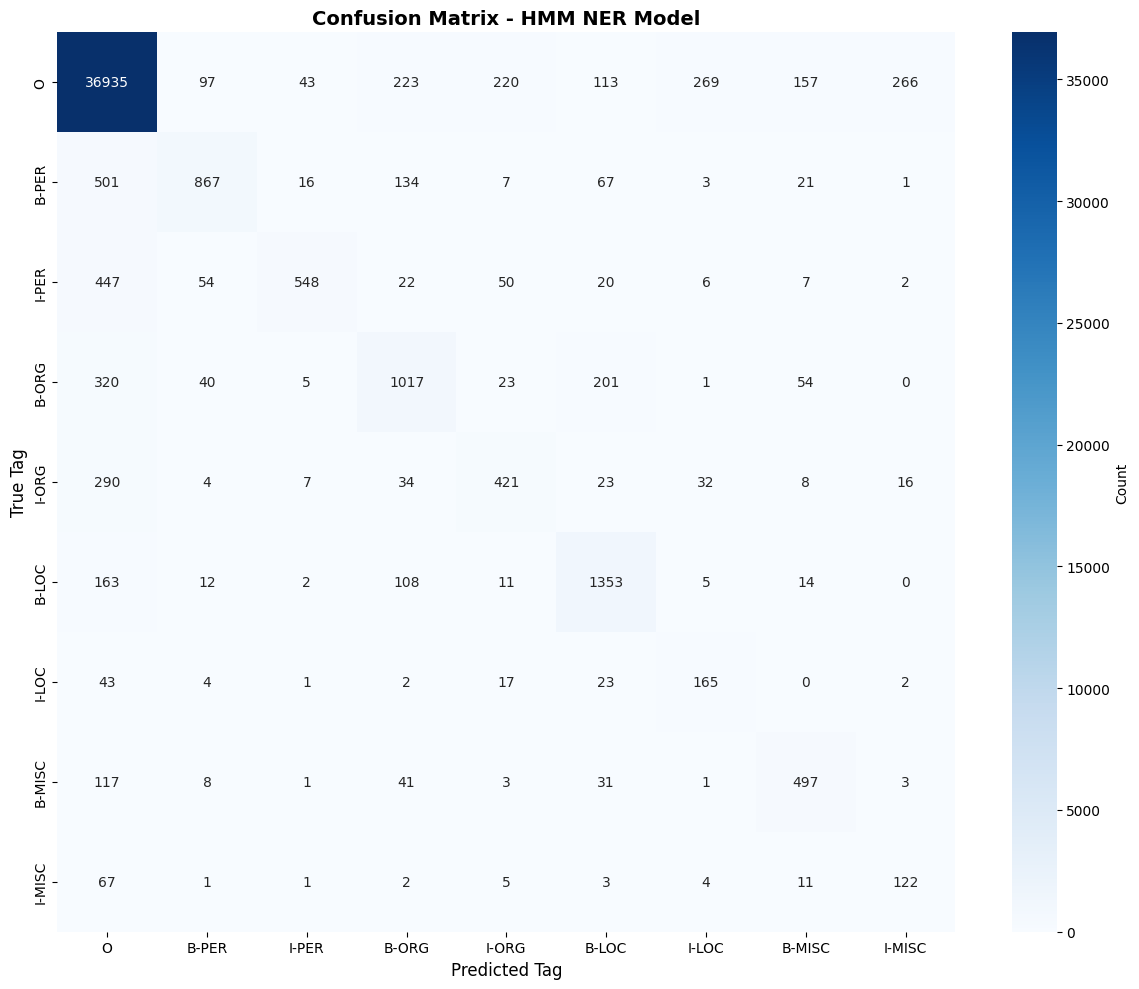

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, sentences, true_tags, idx_to_tag):
    # Get predictions
    predictions = model.predict(sentences)
    flat_preds, flat_true = flatten_predictions(predictions, true_tags)
    
    # Convert to labels
    pred_labels = [idx_to_tag[idx] for idx in flat_preds]
    true_labels = [idx_to_tag[idx] for idx in flat_true]
    
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=list(idx_to_tag.values()))
    
    # Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(idx_to_tag.values()),
                yticklabels=list(idx_to_tag.values()),
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Tag', fontsize=12)
    plt.ylabel('True Tag', fontsize=12)
    plt.title('Confusion Matrix - HMM NER Model', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(hmm_model, test_sentences_processed, test_tags, idx_to_tag)

## 13. Test on Custom Sentences

In [13]:
def predict_custom_sentence(model, sentence, idx_to_tag):
    # Tokenize if string
    if isinstance(sentence, str):
        tokens = sentence.lower().split()
    else:
        tokens = [t.lower() for t in sentence]
    
    # Predict
    pred_tags = model.viterbi(tokens)
    pred_labels = [idx_to_tag[tag] for tag in pred_tags]
    
    # Display
    print("\n" + "="*80)
    print(f"Input: {' '.join(tokens)}")
    print("="*80)
    print(f"{'Token':<20} {'Predicted Tag':<15}")
    print("-"*80)
    for token, tag in zip(tokens, pred_labels):
        print(f"{token:<20} {tag:<15}")
    print("="*80 + "\n")
    
    return list(zip(tokens, pred_labels))

# Test on custom sentences
print("\nTesting HMM on custom sentences:")
print("="*80)

custom_sentences = [
    "Apple is looking at buying a UK startup for $1 billion",
    "Steve Jobs founded Apple in California",
    "The United Nations met in New York yesterday",
    "Barack Obama was president of the United States"
]

for sent in custom_sentences:
    predict_custom_sentence(hmm_model, sent, idx_to_tag)


Testing HMM on custom sentences:

Input: apple is looking at buying a uk startup for $1 billion
Token                Predicted Tag  
--------------------------------------------------------------------------------
apple                B-ORG          
is                   O              
looking              O              
at                   O              
buying               O              
a                    O              
uk                   B-LOC          
startup              O              
for                  O              
$1                   O              
billion              O              


Input: steve jobs founded apple in california
Token                Predicted Tag  
--------------------------------------------------------------------------------
steve                B-PER          
jobs                 O              
founded              O              
apple                B-ORG          
in                   O              
california           B-ORG 